In [1]:
pip install pandas numpy matplotlib seaborn sqlalchemy

Note: you may need to restart the kernel to use updated packages.


# AnalystLab Africa Internship — Week 1-2
## Dataset 1: E-commerce Transactions — Data Cleaning & EDA
### Name: Sakiru Akinpelu

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
df = pd.read_csv('OnlineRetail.csv', encoding='latin1')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (541909, 8)


In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Remove duplicates
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows: 5268
Shape after removing duplicates: (536641, 8)


In [11]:
df = df.dropna(subset=['Description'])
print(f"Shape after dropping missing descriptions: {df.shape}")

Shape after dropping missing descriptions: (535187, 8)


In [12]:
# How many rows have no CustomerID?
missing_customers = df[df['CustomerID'].isna()].shape[0]
print(f"Rows with missing CustomerID: {missing_customers}")

# Fill missing CustomerID with 0 to indicate 'Guest/Unknown'
df['CustomerID'] = df['CustomerID'].fillna(0)
print("Missing CustomerID filled with 0")

Rows with missing CustomerID: 133583
Missing CustomerID filled with 0


In [13]:
# Convert InvoiceDate from text to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert CustomerID from float to integer
df['CustomerID'] = df['CustomerID'].astype(int)

print(df.dtypes)

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int32
Country                object
dtype: object


In [14]:
# Strip extra spaces and convert to title case
df['Description'] = df['Description'].str.strip().str.title()
df['Country'] = df['Country'].str.strip().str.title()

print("Text columns standardized!")

Text columns standardized!


In [15]:
# Separate cancellations (negative quantity) from normal orders
cancellations = df[df['Quantity'] < 0]
df_clean = df[df['Quantity'] > 0]

# Also remove rows where UnitPrice is 0 or negative
df_clean = df_clean[df_clean['UnitPrice'] > 0]

print(f"Cancellation rows removed: {cancellations.shape[0]}")
print(f"Final clean dataset shape: {df_clean.shape}")

Cancellation rows removed: 9725
Final clean dataset shape: (524878, 8)


In [16]:
# Create a TotalPrice column (Quantity x UnitPrice)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
print("TotalPrice column added!")
df_clean.head()

TotalPrice column added!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [17]:
df_clean.to_csv('cleaned_ecommerce.csv', index=False)
print("Cleaned dataset saved as cleaned_ecommerce.csv ✅")

Cleaned dataset saved as cleaned_ecommerce.csv ✅


In [18]:
print(f"Clean dataset shape: {df_clean.shape}")
print(f"\nDate range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")
print(f"\nNumber of unique customers: {df_clean['CustomerID'].nunique()}")
print(f"Number of unique products: {df_clean['Description'].nunique()}")
print(f"Number of unique countries: {df_clean['Country'].nunique()}")
print(f"\nTotal Revenue: ${df_clean['TotalPrice'].sum():,.2f}")

Clean dataset shape: (524878, 9)

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00

Number of unique customers: 4339
Number of unique products: 4015
Number of unique countries: 38

Total Revenue: $10,642,110.80


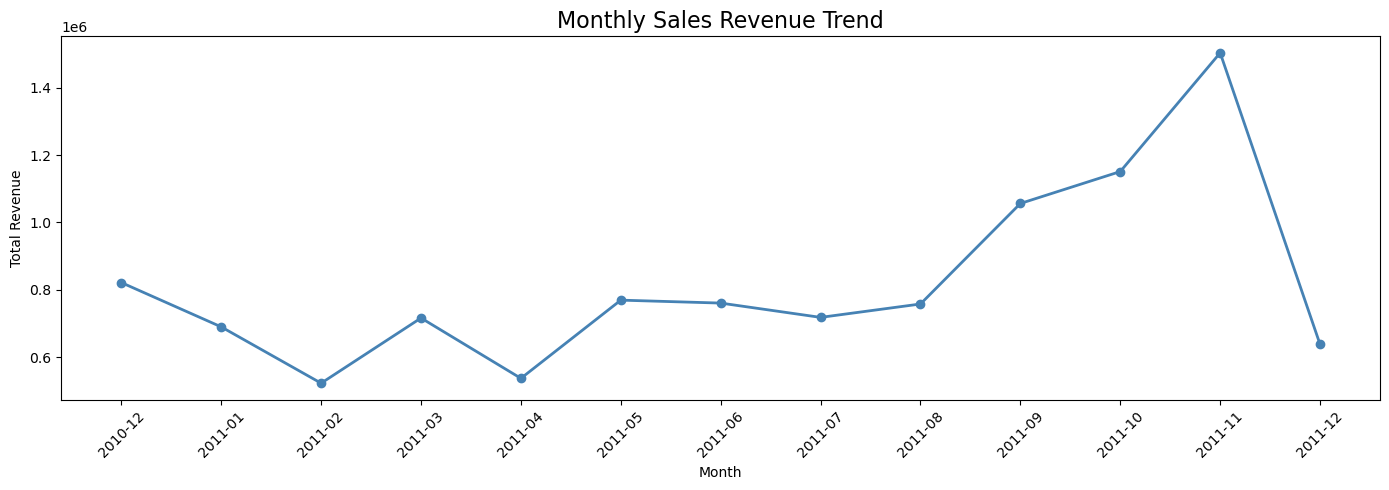

Chart saved!


In [19]:
# Extract month and year from InvoiceDate
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# Group by month
monthly_sales = df_clean.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['YearMonth'], monthly_sales['TotalPrice'], marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Sales Revenue Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png')
plt.show()
print("Chart saved!")

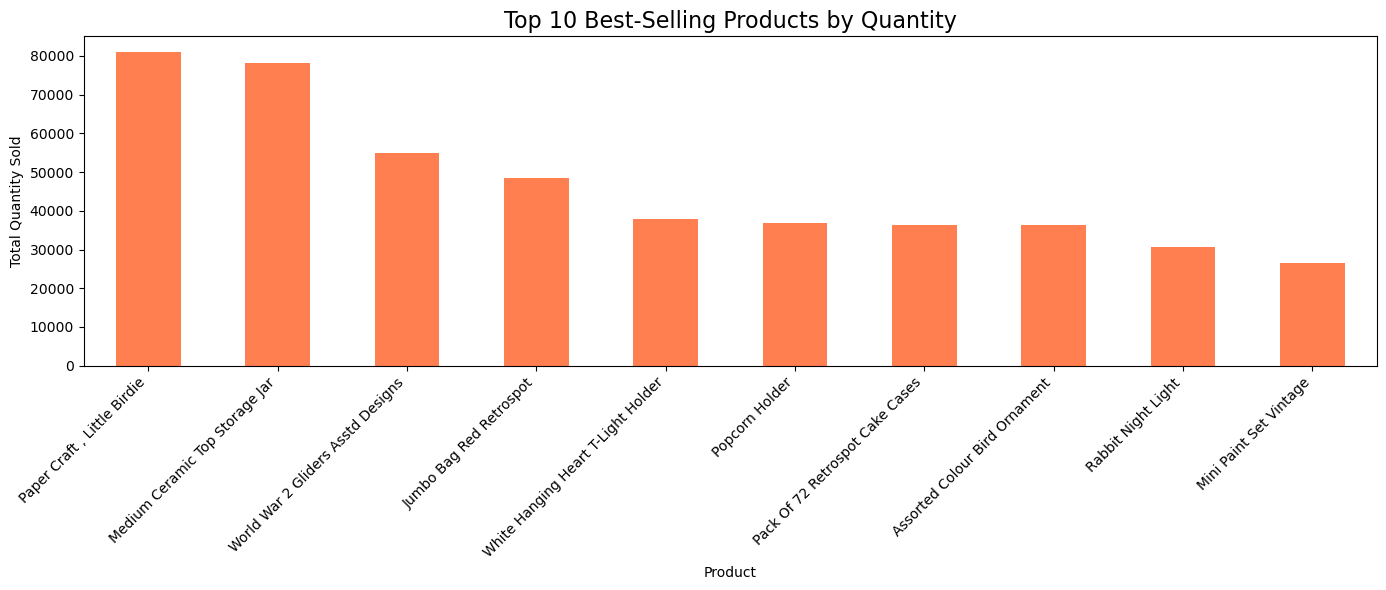

Chart saved!


In [20]:
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 6))
top_products.plot(kind='bar', color='coral')
plt.title('Top 10 Best-Selling Products by Quantity', fontsize=16)
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()
print("Chart saved!")

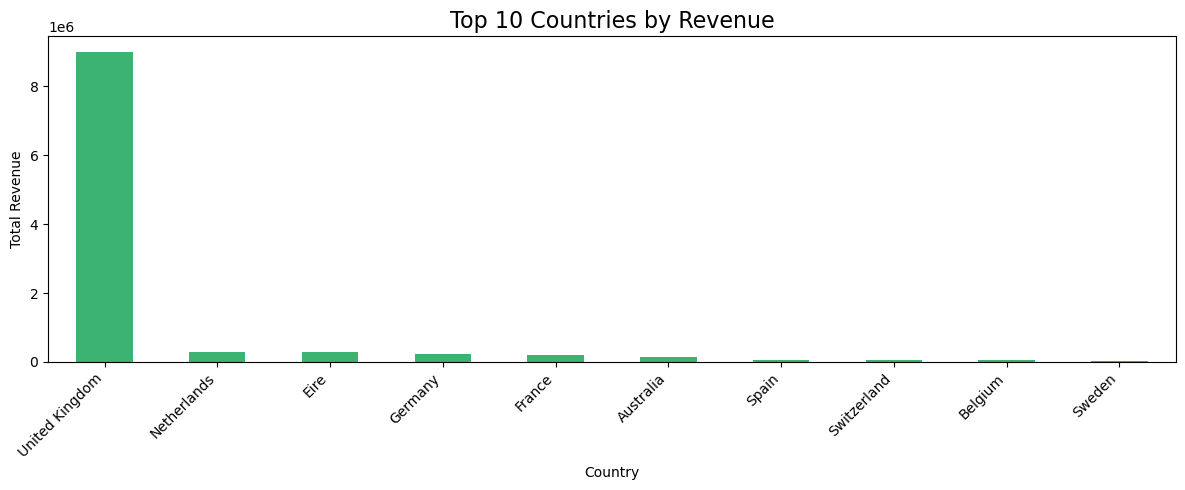

Chart saved!


In [21]:
top_countries = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_countries.plot(kind='bar', color='mediumseagreen')
plt.title('Top 10 Countries by Revenue', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_countries.png')
plt.show()
print("Chart saved!")

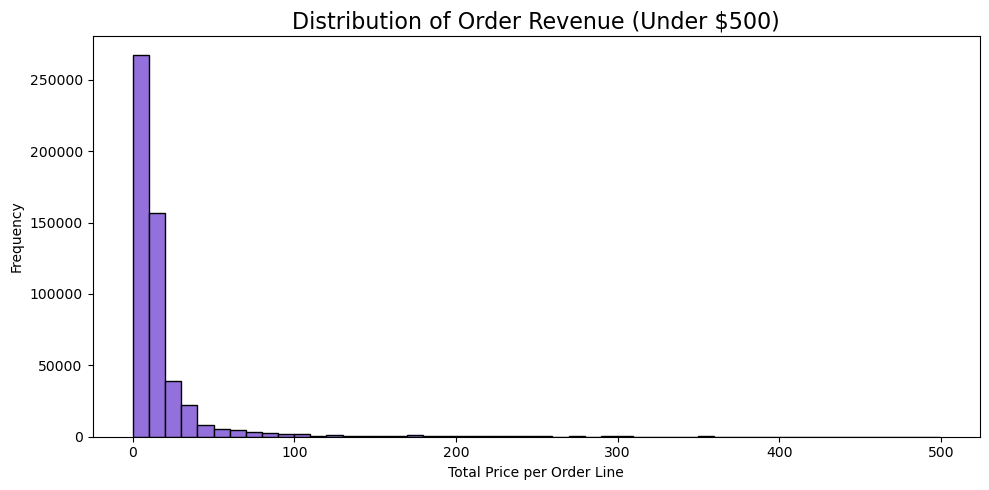

Chart saved!


In [22]:
plt.figure(figsize=(10, 5))
df_clean[df_clean['TotalPrice'] < 500]['TotalPrice'].plot(kind='hist', bins=50, color='mediumpurple', edgecolor='black')
plt.title('Distribution of Order Revenue (Under $500)', fontsize=16)
plt.xlabel('Total Price per Order Line')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('revenue_distribution.png')
plt.show()
print("Chart saved!")

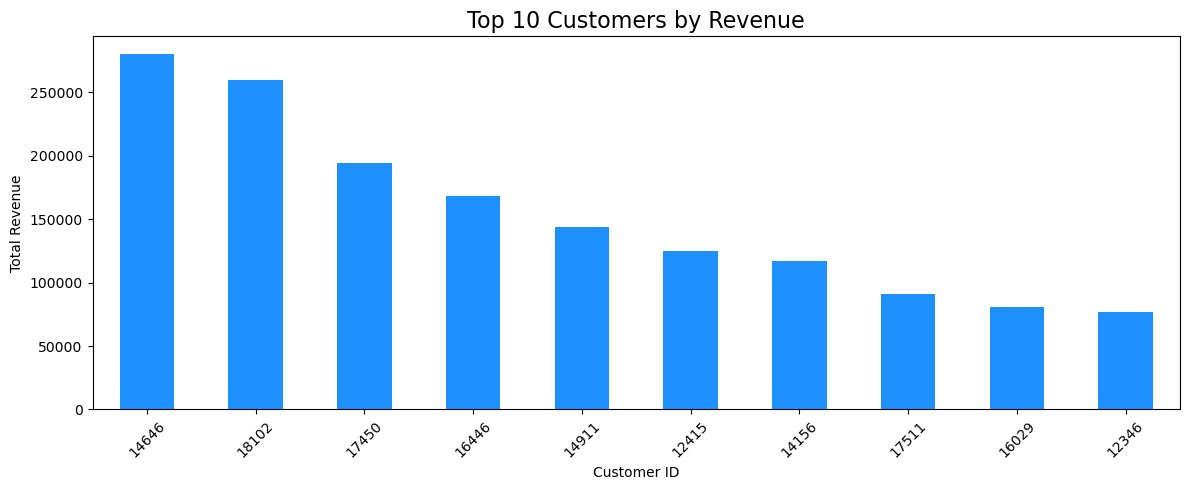

Chart saved!


In [23]:
# Exclude the guest customers (CustomerID = 0)
top_customers = df_clean[df_clean['CustomerID'] != 0].groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_customers.plot(kind='bar', color='dodgerblue')
plt.title('Top 10 Customers by Revenue', fontsize=16)
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_customers.png')
plt.show()
print("Chart saved!")

In [24]:
print("======= KEY INSIGHTS SUMMARY =======\n")
print(f"1. Total Revenue: ${df_clean['TotalPrice'].sum():,.2f}")
print(f"2. Total Orders: {df_clean['InvoiceNo'].nunique():,}")
print(f"3. Total Customers: {df_clean[df_clean['CustomerID'] != 0]['CustomerID'].nunique():,}")
print(f"4. Top Country: {df_clean.groupby('Country')['TotalPrice'].sum().idxmax()}")
print(f"5. Top Product: {df_clean.groupby('Description')['Quantity'].sum().idxmax()}")
print(f"6. Best Sales Month: {df_clean.groupby('YearMonth')['TotalPrice'].sum().idxmax()}")
print(f"7. Top Customer ID: {df_clean[df_clean['CustomerID'] != 0].groupby('CustomerID')['TotalPrice'].sum().idxmax()}")

======= KEY INSIGHTS SUMMARY =======

1. Total Revenue: $10,642,110.80
2. Total Orders: 19,960
3. Total Customers: 4,338
4. Top Country: United Kingdom
5. Top Product: Paper Craft , Little Birdie
6. Best Sales Month: 2011-11
7. Top Customer ID: 14646


In [25]:
!pip install reportlab

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   -------------------------------

In [26]:
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, HRFlowable
from reportlab.lib.enums import TA_CENTER, TA_LEFT

# Create PDF
doc = SimpleDocTemplate(
    "ECommerce_Insight_Report.pdf",
    pagesize=A4,
    rightMargin=2*cm,
    leftMargin=2*cm,
    topMargin=2*cm,
    bottomMargin=2*cm
)

styles = getSampleStyleSheet()

# Custom styles
title_style = ParagraphStyle('Title', parent=styles['Title'], fontSize=16, textColor=colors.HexColor('#1a3c5e'), alignment=TA_CENTER, spaceAfter=6)
subtitle_style = ParagraphStyle('Subtitle', parent=styles['Normal'], fontSize=10, textColor=colors.HexColor('#444444'), alignment=TA_CENTER, spaceAfter=4)
section_style = ParagraphStyle('Section', parent=styles['Heading2'], fontSize=12, textColor=colors.HexColor('#1a3c5e'), spaceBefore=12, spaceAfter=4)
body_style = ParagraphStyle('Body', parent=styles['Normal'], fontSize=9.5, leading=14, spaceAfter=6)
insight_style = ParagraphStyle('Insight', parent=styles['Normal'], fontSize=9.5, leading=14, spaceAfter=6, leftIndent=10)

# Content
content = []

# Header
content.append(Paragraph("E-Commerce Transactions — Insight Report", title_style))
content.append(Paragraph("AnalystLab Africa Data Analytics Internship | Week 1–2", subtitle_style))
content.append(Paragraph("Prepared by: Sakiru Akinpelu", subtitle_style))
content.append(Paragraph("Date: May 2026", subtitle_style))
content.append(HRFlowable(width="100%", thickness=1.5, color=colors.HexColor('#1a3c5e'), spaceAfter=10))

# Dataset Overview
content.append(Paragraph("1. Dataset Overview", section_style))
overview_data = [
    ['Metric', 'Value'],
    ['Source', 'UCI Machine Learning Repository — Online Retail Dataset'],
    ['Total Records (Raw)', '541,909 rows'],
    ['Total Records (Cleaned)', str(f"{df_clean.shape[0]:,} rows")],
    ['Columns', '8 (InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country)'],
    ['Date Range', f"{df_clean['InvoiceDate'].min().strftime('%B %d, %Y')} – {df_clean['InvoiceDate'].max().strftime('%B %d, %Y')}"],
    ['Unique Customers', f"{df_clean[df_clean['CustomerID'] != 0]['CustomerID'].nunique():,}"],
    ['Unique Products', f"{df_clean['Description'].nunique():,}"],
    ['Countries Covered', f"{df_clean['Country'].nunique():,}"],
]
overview_table = Table(overview_data, colWidths=[5*cm, 12*cm])
overview_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#1a3c5e')),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('FONTSIZE', (0, 0), (-1, -1), 9),
    ('BACKGROUND', (0, 1), (-1, -1), colors.HexColor('#f4f8fc')),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.HexColor('#f4f8fc'), colors.white]),
    ('GRID', (0, 0), (-1, -1), 0.5, colors.HexColor('#cccccc')),
    ('PADDING', (0, 0), (-1, -1), 5),
]))
content.append(overview_table)

# Data Cleaning Summary
content.append(Paragraph("2. Data Cleaning Summary", section_style))
cleaning_data = [
    ['Issue Identified', 'Action Taken'],
    ['5,268 duplicate rows', 'Removed using drop_duplicates()'],
    ['1,454 missing Descriptions', 'Rows dropped — no business value without product name'],
    ['135,080 missing CustomerIDs', 'Filled with 0 to represent guest/unknown customers'],
    ['Negative Quantity values (returns)', 'Separated and removed from main dataset'],
    ['Negative & zero UnitPrice anomalies', 'Removed — invalid for revenue analysis'],
    ['InvoiceDate stored as text (object)', 'Converted to datetime format'],
    ['CustomerID stored as float', 'Converted to integer'],
    ['Inconsistent text formatting', 'Standardized to Title Case for Description & Country'],
]
cleaning_table = Table(cleaning_data, colWidths=[8.5*cm, 8.5*cm])
cleaning_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#1a3c5e')),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('FONTSIZE', (0, 0), (-1, -1), 9),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.HexColor('#f4f8fc'), colors.white]),
    ('GRID', (0, 0), (-1, -1), 0.5, colors.HexColor('#cccccc')),
    ('PADDING', (0, 0), (-1, -1), 5),
]))
content.append(cleaning_table)

# Key Insights
content.append(Paragraph("3. Key Insights", section_style))

insights = [
    ("Insight 1 — UK Dominates Revenue",
     "The United Kingdom is overwhelmingly the top revenue-generating country, accounting for the vast majority of the $10,642,110.80 total revenue. This indicates heavy market concentration and highlights international expansion as a key growth opportunity."),
    ("Insight 2 — Sales are Strongly Seasonal",
     "November 2011 was the best performing sales month, consistent with pre-Christmas shopping and Black Friday demand. The business should prioritize inventory buildup and targeted marketing campaigns ahead of Q4 each year."),
    ("Insight 3 — Small Customer Base Drives Large Revenue",
     "Only 4,338 unique customers generated over $10.6 million in revenue — an average spend of approximately $2,452 per customer. This signals a high-value, loyal customer base where retention strategies would yield significant returns."),
    ("Insight 4 — Paper Craft Little Birdie is the Top Product",
     "This product recorded the highest quantity sold across the entire dataset. Craft and gift items dominate demand, suggesting the retailer should ensure consistent stock availability for this product category."),
    ("Insight 5 — Business Faces Concentration Risk",
     "With revenue heavily concentrated in the UK market and among a relatively small customer pool, the business is exposed to concentration risk. Diversifying into new markets and acquiring new customers should be a strategic priority."),
]

for title, body in insights:
    content.append(Paragraph(f"<b>{title}</b>", insight_style))
    content.append(Paragraph(body, insight_style))
    content.append(Spacer(1, 4))

# Footer line
content.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#1a3c5e'), spaceBefore=10))
content.append(Paragraph("AnalystLab Africa Internship Program | Data Analytics Track | May 2026", subtitle_style))

# Build PDF
doc.build(content)
print("PDF Report generated successfully! ✅")

PDF Report generated successfully! ✅
